## Quali sono le 3 skills più richieste per i ruoli con dati?

Metodologia:
1. Pulire la colonna skill
2. Calcolare il conteggio di skill basato su `job_title_short`
3. Calcolare la percentuale di skill
4. Creare un grafico 

In [2]:
# Importare le librerie necessarie
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from typing import cast

# Caricare il dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = cast(pd.DataFrame, dataset['train'].to_pandas())

# Pulire i dati
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [3]:
df_US = df[df['job_country'] == 'United States'].copy()
df_skills = df_US.explode('job_skills')
df_skills_count = df_skills.groupby(['job_title_short', 'job_skills']).size().reset_index(name='count').sort_values(by='count', ascending=False)
df_skills_count.head(10)

,job_title_short,job_skills,count
886,Data Scientist,python,42379
472,Data Analyst,sql,34452
921,Data Scientist,sql,30034
351,Data Analyst,excel,27519
890,Data Scientist,r,26022
694,Data Engineer,sql,23958
659,Data Engineer,python,22762
483,Data Analyst,tableau,19311
438,Data Analyst,python,18382
530,Data Engineer,aws,15018


In [4]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = job_titles[:3]
job_titles.sort()
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

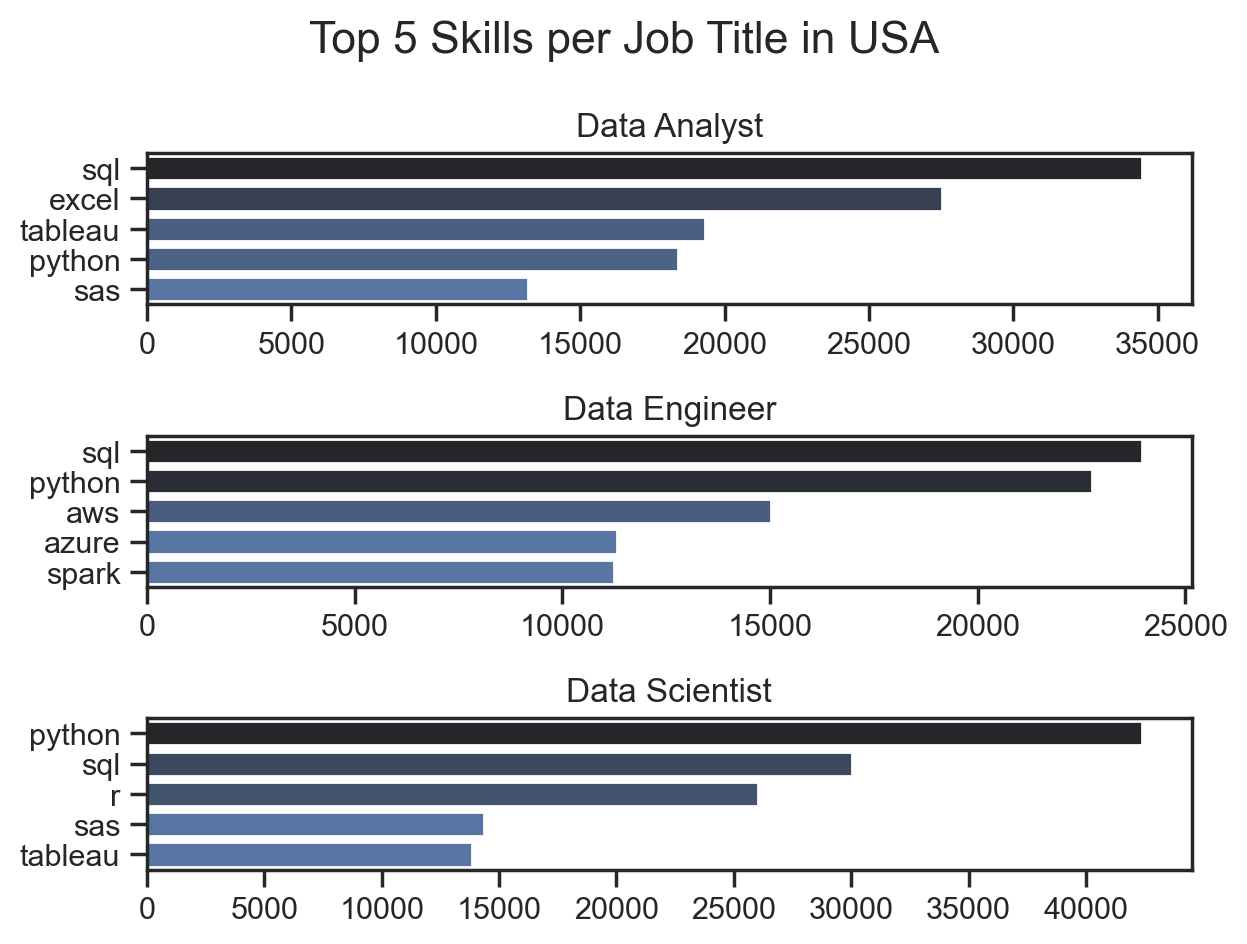

In [5]:
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style='ticks')
fig, ax = plt.subplots(len(job_titles), 1)
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    sns.barplot(x='count', y='job_skills', data=df_plot, ax=ax[i], hue='count', palette = 'dark:b_r', legend=False)
    ax[i].set_title(job_title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
fig.suptitle('Top 5 Skills per Job Title in USA', fontsize=16)
fig.tight_layout()

In [6]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

In [7]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how = 'left', on = 'job_title_short')
df_skills_perc['skill_perc'] = df_skills_perc['count'] / df_skills_perc['jobs_total'] * 100
df_skills_perc

,job_title_short,job_skills,count,jobs_total,skill_perc
0,Data Scientist,python,42379,58830,72.036376
1,Data Analyst,sql,34452,67816,50.802171
2,Data Scientist,sql,30034,58830,51.052184
3,Data Analyst,excel,27519,67816,40.578919
4,Data Scientist,r,26022,58830,44.232534
...,...,...,...,...,...
1865,Senior Data Engineer,asp.net core,1,9289,0.010765
1866,Cloud Engineer,ms access,1,423,0.236407
1867,Machine Learning Engineer,graphql,1,921,0.108578
1868,Senior Data Scientist,mariadb,1,12946,0.007724


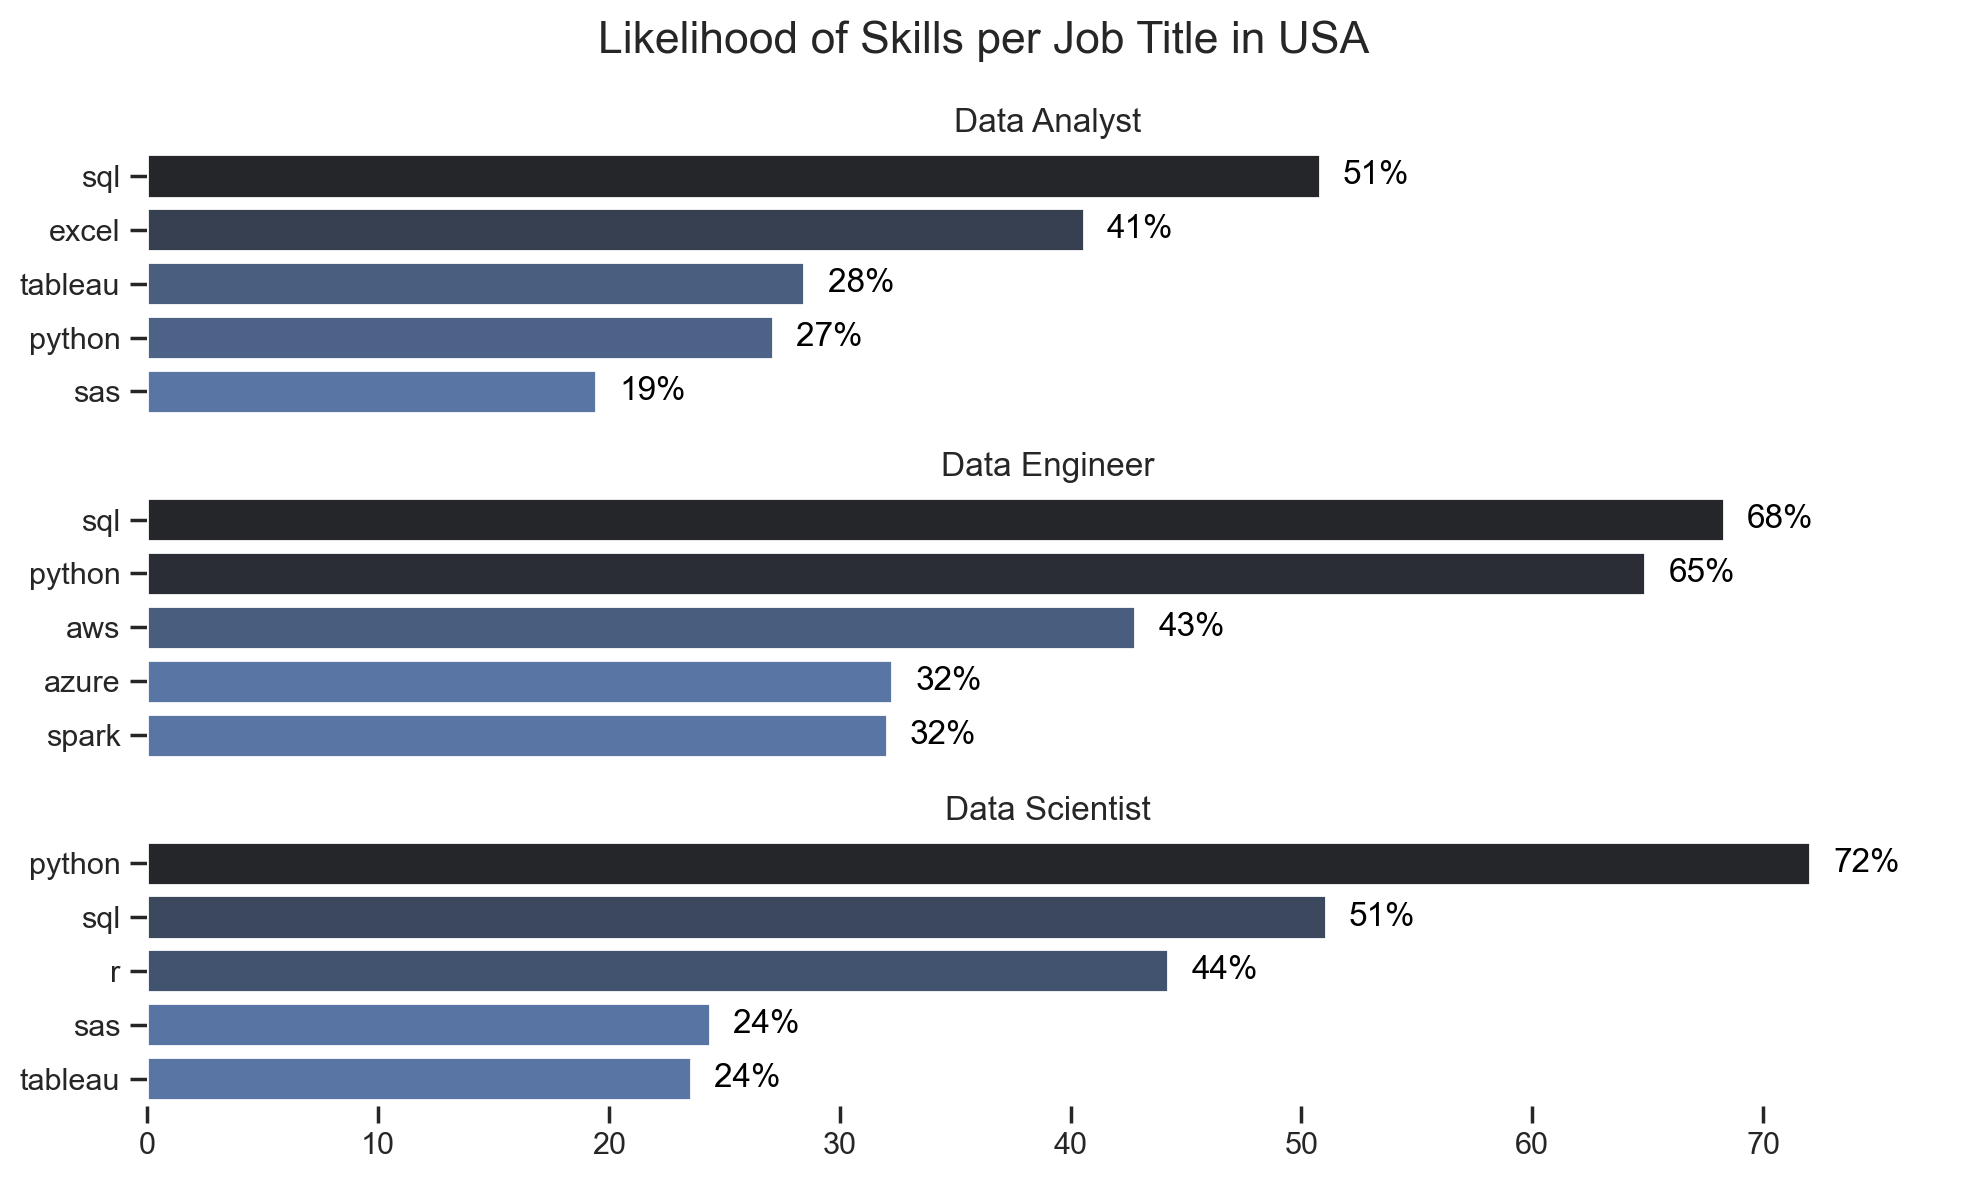

In [10]:
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style='ticks')
fig, ax = plt.subplots(len(job_titles), 1, figsize=(10, 6))
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(x='skill_perc', y='job_skills', data=df_plot, ax=ax[i], hue='skill_perc', palette = 'dark:b_r', legend=False)
    sns.despine(left=True, bottom=True) # rimuove le spine per un look più pulito
    ax[i].set_title(job_title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].set_xlim(0, 78)
    
    if i < len(job_titles) - 1:
        ax[i].set_xticks([])
    for n, v in enumerate(df_plot['skill_perc']):
        ax[i].text(v + 1, n, f'{v:.0f}%', color='black', va='center')
fig.suptitle('Likelihood of Skills per Job Title in USA', fontsize=16)
fig.tight_layout(h_pad=1)
# per salvarlo in svg in locale
plt.savefig('images/skills_perc_job_title.svg', format='svg')